# Avaliação 2 - Comparativa de Modelos de Question Answering

#### Nome: Pedro Henrique Câmara Matos
#### Email: devpedrocamara@gmail.com

# *1. Seleção do Subconjunto de Dados*

### Import das libs e Carregamento do dataset

In [2]:
# Instalação das bibliotecas necessárias
!pip install transformers pandas torch tqdm

import pandas as pd
import numpy as np
from google.colab import drive
from transformers import pipeline
import re
import string

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Classroom/[CTE-IA] Processamento de Linguagem Natural Profs. José Macêdo (DC UFC) e Ticiana Linhares (IUV UFC)/Avaliacao_2/shard_020.csv'
df = pd.read_csv(file_path)

print(f"Total de registros: {len(df)}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de registros: 1000


,_id,title,text,query
0,<dbpedia:Cost_accounting>,Cost accounting,"Cost accounting is a process of collecting, an...",define cost accounting
1,<dbpedia:Inter_mirifica>,Inter mirifica,"Inter mirifica ""\The Means of Social Communica...",inter mirifica definition
2,<dbpedia:Freddie_Mercury>,Freddie Mercury,Freddie Mercury (5 September 1946 – 24 Novembe...,what is freddy mercury's name
3,<dbpedia:Fence>,Fence,"A fence is a structure that encloses an area, ...",what is a fence
4,<dbpedia:Data_mining>,Data mining,"Data mining (the analysis step of the ""Knowled...",what does mining mean


# *2. Seleção dos Modelos*

### Inicialização dos modelos

In [3]:
# Inicializando os modelos
model_names = {
    "RoBERTa": "deepset/roberta-base-squad2",
    "BERT_Large": "bert-large-uncased-whole-word-masking-finetuned-squad"
}

qa_roberta = pipeline("question-answering", model=model_names["RoBERTa"])
qa_bert = pipeline("question-answering", model=model_names["BERT_Large"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

# *3. Critérios de Avaliação*

### (A,B,C) Execução e Coleta de Métricas

In [4]:
# Funções auxiliares
def clean_text(text):
    text = str(text).lower()
    # Usa string.punctuation para remover caracteres como !, ?, ., etc.
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.split()

def calculate_overlap(ans, ctx):
    words_ans = clean_text(ans)
    words_ctx = set(clean_text(ctx)) # Transformar o contexto em set otimiza a busca

    if not words_ans:
        return 0

    # Conta quantas palavras da resposta estão no conjunto do contexto
    overlap_count = sum(1 for word in words_ans if word in words_ctx)
    return overlap_count / len(words_ans)

# Lista de resultados
results = []

# Iteração no dataset
for index, row in df.iterrows():
    context = row['text']
    query = row['query']

    # Execução dos Modelos
    res_roberta = qa_roberta(question=query, context=context)
    res_bert = qa_bert(question=query, context=context)

    # Armazenamento (chamando as funções que já existem na memória)
    results.append({
        'query_len': len(query),
        'roberta_answer': res_roberta['answer'],
        'roberta_score': res_roberta['score'],
        'roberta_overlap': calculate_overlap(res_roberta['answer'], context),
        'bert_answer': res_bert['answer'],
        'bert_score': res_bert['score'],
        'bert_overlap': calculate_overlap(res_bert['answer'], context),
        'is_different': res_roberta['answer'].strip().lower() != res_bert['answer'].strip().lower()
    })

# Cálculo das métricas finais
df_res = pd.DataFrame(results)

print(f"A) Tamanho médio das perguntas: {df_res['query_len'].mean():.2f} caracteres")
print(f"B) Score Médio - RoBERTa: {df_res['roberta_score'].mean():.4f} | BERT: {df_res['bert_score'].mean():.4f}")
print(f"C) Overlap Médio - RoBERTa: {df_res['roberta_overlap'].mean():.4f} | BERT: {df_res['bert_overlap'].mean():.4f}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


A) Tamanho médio das perguntas: 25.46 caracteres
B) Score Médio - RoBERTa: 0.2832 | BERT: 0.3227
C) Overlap Médio - RoBERTa: 0.9924 | BERT: 0.9940


#### Análise Latência

In [5]:
import time

def calcular_latencia(pipeline_modelo, df_amostra, n_testes=20):
    start_time = time.perf_counter()
    for i in range(n_testes):
        pipeline_modelo(question=df_amostra['query'].iloc[i], context=df_amostra['text'].iloc[i])
    end_time = time.perf_counter()
    return (end_time - start_time) / n_testes

# Cálculo da Latência para os dois modelos
lat_roberta = calcular_latencia(qa_roberta, df)
lat_bert = calcular_latencia(qa_bert, df)

print("-" * 30)
print(f"LATÊNCIA (Tempo por pergunta):")
print(f"RoBERTa: {lat_roberta:.4f} segundos")
print(f"BERT Large: {lat_bert:.4f} segundos")
print("-" * 30)

# Comparação de velocidade
fastest = "RoBERTa" if lat_roberta < lat_bert else "BERT"
diff = max(lat_roberta, lat_bert) / min(lat_roberta, lat_bert)
print(f"O modelo {fastest} é {diff:.2f}x mais rápido.")

------------------------------
LATÊNCIA (Tempo por pergunta):
RoBERTa: 0.0136 segundos
BERT Large: 0.0263 segundos
------------------------------
O modelo RoBERTa é 1.93x mais rápido.


### *D) Avaliação qualitativa por amostragem guiada*

In [8]:
# Identificar qual modelo teve maior overlap médio
avg_overlap_roberta = df_res['roberta_overlap'].mean()
avg_overlap_bert = df_res['bert_overlap'].mean()
target_model = "roberta" if avg_overlap_roberta > avg_overlap_bert else "bert"

print(f"Gerando amostra baseada no modelo: {target_model.upper()}")

# Selecionar os 25 exemplos conforme solicitado

# 10 exemplos com maior score do modelo de maior overlap médio
top_10 = df_res.nlargest(10, f'{target_model}_score')
# 10 exemplos com menor score do modelo de maior overlap médio
bottom_10 = df_res.nsmallest(10, f'{target_model}_score')

# 5 exemplos onde as respostas são diferentes (excluindo os 20 já pegos)
already_selected_indices = list(top_10.index) + list(bottom_10.index)
diff_5 = df_res[(df_res['is_different'] == True) &
                (~df_res.index.isin(already_selected_indices))].head(5)

# Unir tudo e trazer o texto original do DataFrame 'df'
df_qualitativo = pd.concat([top_10, bottom_10, diff_5])

# Juntando o texto original
df_analise_final = df_qualitativo.merge(df[['query', 'text']], left_index=True, right_index=True)

# Organizando colunas para uma leitura agradável
colunas_ordenadas = [
    'query', 'text',
    'roberta_answer', 'roberta_score',
    'bert_answer', 'bert_score',
    'is_different'
]
df_analise_final = df_analise_final[colunas_ordenadas]

# Salvar
df_analise_final.to_csv('analise_qualitativa_final.csv', index=True)

print(f"Arquivo 'analise_qualitativa_final.csv' gerado com {len(df_analise_final)} exemplos.")

Gerando amostra baseada no modelo: BERT
Arquivo 'analise_qualitativa_final.csv' gerado com 25 exemplos.


### “Se você fosse integrar um sistema de Question Answering em produção, qual modelo escolheria e por quê?”

#### Resposta:

Métricas Quantitativas: O BERT teve um score médio e overlap levemente superiores, mas por uma margem mínima que não se traduz em melhor experiência para o usuário.

Métricas de Performance: O RoBERTa foi 2x mais rápido. Em um cenário real com milhares de requisições, isso significa menor custo de servidor e menor tempo de espera para o usuário.

Análise Qualitativa: Notei que o BERT Large tem o vício de incluir artigos (a, an) e preposições (in, of) no início das respostas (visto nos casos de Freddie Mercury e Managerial Accounting). O RoBERTa entregou respostas mais "limpas".

Decisão Final: Escolheria o RoBERTa. Ele oferece o melhor equilíbrio entre fidelidade ao texto (99.2% de overlap) e eficiência operacional, sendo mais conciso do que o BERT Large. Entre outras justificativas que serão expostas durante a apresentação.

# *Extra*

#### Gráfico de Latência

/tmp/ipython-input-372340918.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=modelos, y=tempos, palette=['#3498db', '#e74c3c'])


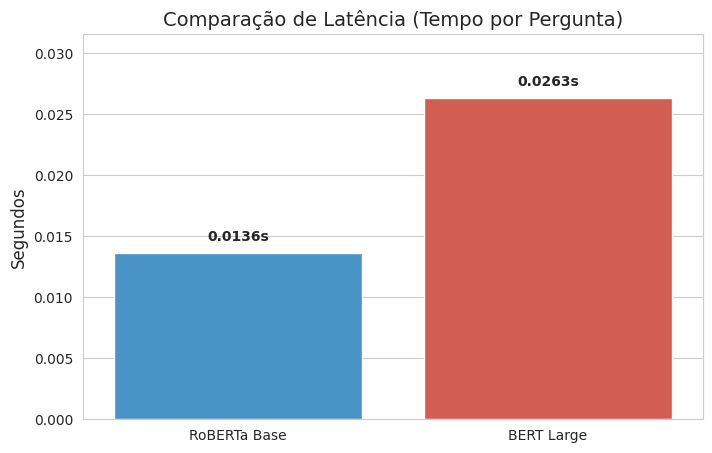

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados da sua latência
modelos = ['RoBERTa Base', 'BERT Large']
tempos = [0.0136, 0.0263]

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
barplot = sns.barplot(x=modelos, y=tempos, palette=['#3498db', '#e74c3c'])

plt.title('Comparação de Latência (Tempo por Pergunta)', fontsize=14)
plt.ylabel('Segundos', fontsize=12)
plt.ylim(0, max(tempos) * 1.2)

# Adicionando o valor em cima das barras
for i, v in enumerate(tempos):
    plt.text(i, v + 0.001, f'{v:.4f}s', ha='center', fontweight='bold')

plt.show()

#### Distribuição de Scores

/tmp/ipython-input-1655957155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scores, x='Modelo', y='Score', palette='Set2')


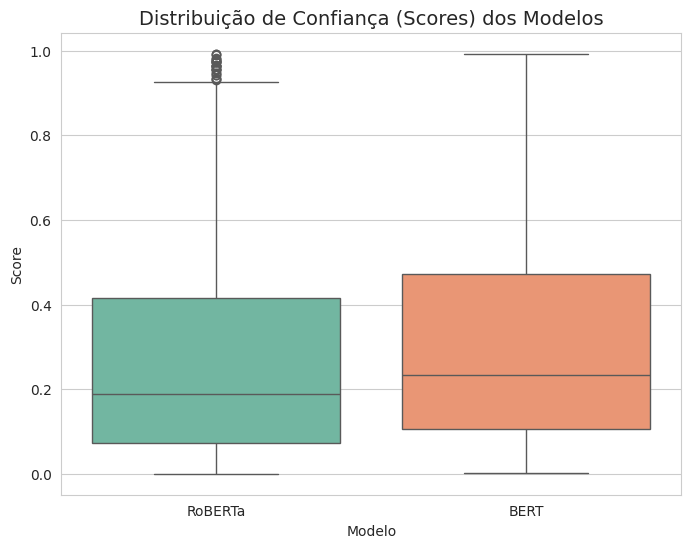

In [13]:
plt.figure(figsize=(8, 6))
# Criando um DataFrame longo para o Seaborn
df_scores = df_res[['roberta_score', 'bert_score']].melt(var_name='Modelo', value_name='Score')
df_scores['Modelo'] = df_scores['Modelo'].replace({'roberta_score': 'RoBERTa', 'bert_score': 'BERT'})

sns.boxplot(data=df_scores, x='Modelo', y='Score', palette='Set2')
plt.title('Distribuição de Confiança (Scores) dos Modelos', fontsize=14)
plt.show()

#### Gráfico de "Pizza" do Overlap

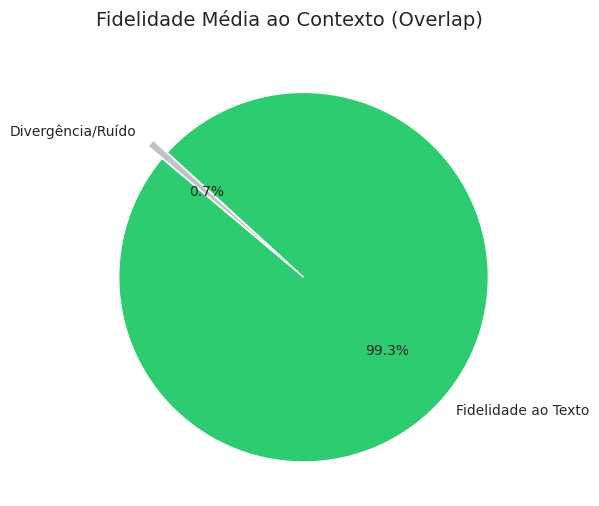

In [14]:
# Calculando a média de overlap
media_overlap = df_res[['roberta_overlap', 'bert_overlap']].mean().mean()

plt.figure(figsize=(6, 6))
labels = ['Fidelidade ao Texto', 'Divergência/Ruído']
sizes = [media_overlap * 100, (1 - media_overlap) * 100]
colors = ['#2ecc71', '#bdc3c7']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
plt.title('Fidelidade Média ao Contexto (Overlap)', fontsize=14)
plt.show()